# SynthDetect — Ensemble тренування (ResNet-50 + ViT-B/16) + повна оцінка

Цей ноутбук:
1. Тренує **ResNet-50** і **ViT-B/16** на датасеті `Parveshiiii/AI-vs-Real`
2. Завантажує існуючу **EfficientNet-B0 (v2)** якщо доступна
3. Оцінює всі 3 моделі індивідуально на тестовій вибірці
4. Будує **ансамбль** (середнє ймовірностей) і оцінює його
5. Генерує матриці помилок, ROC-криві, метрики JSON для слайдів


In [ ]:
# Встановлення залежностей
!pip install -q datasets pillow scikit-learn matplotlib seaborn 2>&1 | tail -3


In [ ]:
import os
import json
import time
from pathlib import Path
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import transforms
from torchvision.models import (
    resnet50, ResNet50_Weights,
    vit_b_16, ViT_B_16_Weights,
    efficientnet_b0,
)

from datasets import load_dataset
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

torch.backends.cudnn.benchmark = True
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# === Конфігурація ===
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 2
IMAGE_SIZE = 224
BATCH_SIZE_CNN = 32       # для ResNet-50
BATCH_SIZE_VIT = 16       # ViT-B/16 важчий за памʼяттю — менший batch
NUM_WORKERS = 2

# Hyperparameters
EPOCHS = 5
LR_START_CNN = 1e-4       # ResNet-50 з ImageNet
LR_START_VIT = 5e-5       # ViT краще тренується з меншим LR
LR_END = 1e-6
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 2

# Конвенція класів (як у v2: 0 = synthetic / ai, 1 = real)
CLASS_SYNTHETIC = 0
CLASS_REAL = 1

# Output dir (Kaggle або Colab)
if os.path.exists('/kaggle/working'):
    OUTPUT_DIR = Path('/kaggle/working')
elif os.path.exists('/content'):
    OUTPUT_DIR = Path('/content')
else:
    OUTPUT_DIR = Path('.')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output: {OUTPUT_DIR}")

# Опційно: існуюча v2 модель (для участі у ансамблі)
V2_PATH_CANDIDATES = [
    '/kaggle/input/synthdetect-v2/efficientnet_b0_synthdetect_v2.pth',
    '/kaggle/input/synthdetect-v2-model/efficientnet_b0_synthdetect_v2.pth',
    '/content/efficientnet_b0_synthdetect_v2.pth',
    './efficientnet_b0_synthdetect_v2.pth',
]
V2_PATH = next((p for p in V2_PATH_CANDIDATES if os.path.exists(p)), None)
if V2_PATH:
    print(f"✓ v2.pth знайдено: {V2_PATH}")
else:
    print("⚠ v2.pth НЕ знайдено — ансамбль буде з 2 моделей (ResNet + ViT)")
    print("  Шукав у:", V2_PATH_CANDIDATES)


Output: /content
✓ v2.pth знайдено: /content/efficientnet_b0_synthdetect_v2.pth


In [ ]:
# Завантаження датасету
print("Завантажую AI-vs-Real з HuggingFace...")
ds = load_dataset('Parveshiiii/AI-vs-Real', verification_mode='no_checks')
print(f"Splits: {list(ds.keys())}")
print(f"Examples: {len(ds['train'])}")
print(f"Columns: {ds['train'].column_names}")

# Перевірка маппінгу class label
first = ds['train'][0]
print(f"First example: image={first['image'].size}, label={first['binary_label']}")
print(f"\nFeatures: {ds['train'].features}")


Завантажую AI-vs-Real з HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/309M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/826M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/805M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

Splits: ['train']
Examples: 13999
Columns: ['image', 'binary_label']
First example: image=(640, 426), label=1

Features: {'image': Image(mode=None, decode=True), 'binary_label': Value('int64')}


In [ ]:
# Stratified split 80/10/10 (train/val/test)
all_indices = list(range(len(ds['train'])))
all_labels = list(ds['train']['binary_label'])

train_idx, rest_idx, train_labels, rest_labels = train_test_split(
    all_indices, all_labels, test_size=0.20, stratify=all_labels, random_state=SEED
)
val_idx, test_idx, val_labels, test_labels_split = train_test_split(
    rest_idx, rest_labels, test_size=0.50, stratify=rest_labels, random_state=SEED
)

print(f"Train: {len(train_idx)} ({sum(train_labels)} real / {len(train_labels) - sum(train_labels)} synthetic)")
print(f"Val:   {len(val_idx)} ({sum(val_labels)} real / {len(val_labels) - sum(val_labels)} synthetic)")
print(f"Test:  {len(test_idx)} ({sum(test_labels_split)} real / {len(test_labels_split) - sum(test_labels_split)} synthetic)")


Train: 11199 (8533 real / 2666 synthetic)
Val:   1400 (1067 real / 333 synthetic)
Test:  1400 (1066 real / 334 synthetic)


In [ ]:
# Augmentations
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [ ]:
class HFImageDataset(Dataset):
    """Wrapper для HuggingFace dataset з підтримкою PyTorch DataLoader."""
    def __init__(self, hf_split, indices, transform):
        self.split = hf_split
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        item = self.split[self.indices[idx]]
        img = item['image']
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img = self.transform(img)
        return img, item['binary_label']

# Train/val/test datasets
train_ds_cnn = HFImageDataset(ds['train'], train_idx, train_transform)
val_ds = HFImageDataset(ds['train'], val_idx, eval_transform)
test_ds = HFImageDataset(ds['train'], test_idx, eval_transform)

# Окремі loader-и для CNN (batch 32) і ViT (batch 16)
train_loader_cnn = DataLoader(train_ds_cnn, batch_size=BATCH_SIZE_CNN, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
train_loader_vit = DataLoader(train_ds_cnn, batch_size=BATCH_SIZE_VIT, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_cnn = DataLoader(val_ds, batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_vit = DataLoader(val_ds, batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches (CNN): {len(train_loader_cnn)}")
print(f"Train batches (ViT): {len(train_loader_vit)}")


Train batches (CNN): 350
Train batches (ViT): 700


In [ ]:
# Утиліти для тренування
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses, correct, total = [], 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return np.mean(losses), correct / total

@torch.no_grad()
def eval_loss_acc(model, loader, criterion, device):
    model.eval()
    losses, correct, total = [], 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        losses.append(criterion(logits, labels).item())
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return np.mean(losses), correct / total

def train_model(model, train_loader, val_loader, epochs, lr_start, lr_end, device, name='model'):
    optimizer = AdamW(model.parameters(), lr=lr_start, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr_end)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc, best_state, patience = 0, None, 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = eval_loss_acc(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        print(f"[{name}] Epoch {epoch}/{epochs} ({time.time()-t0:.1f}s) "
              f"train: loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val: loss={val_loss:.4f} acc={val_acc:.4f} | lr={current_lr:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping ({EARLY_STOPPING_PATIENCE} епох без покращення)")
                break

    return history, best_state, best_val_acc


In [ ]:
# === ТРЕНУЮ RESNET-50 ===
print("=" * 70)
print("RESNET-50")
print("=" * 70)

model_r50 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model_r50.fc = nn.Linear(model_r50.fc.in_features, NUM_CLASSES)
model_r50 = model_r50.to(DEVICE)
print(f"Параметри: {sum(p.numel() for p in model_r50.parameters()):,}")

history_r50, best_state_r50, best_val_r50 = train_model(
    model_r50, train_loader_cnn, val_loader_cnn,
    EPOCHS, LR_START_CNN, LR_END, DEVICE, name='ResNet50'
)

model_r50.load_state_dict(best_state_r50)
r50_path = OUTPUT_DIR / 'resnet50_synthdetect.pth'
torch.save(best_state_r50, r50_path)
print(f"\n✓ ResNet-50 збережено: {r50_path}")
print(f"  Best val_acc: {best_val_r50:.4f}")

torch.cuda.empty_cache()


RESNET-50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


Параметри: 23,512,130
[ResNet50] Epoch 1/5 (249.2s) train: loss=0.0909 acc=0.9662 | val: loss=0.0267 acc=0.9886 | lr=1.00e-04
[ResNet50] Epoch 2/5 (232.7s) train: loss=0.0255 acc=0.9922 | val: loss=0.0226 acc=0.9936 | lr=9.05e-05
[ResNet50] Epoch 3/5 (231.8s) train: loss=0.0098 acc=0.9971 | val: loss=0.0124 acc=0.9964 | lr=6.58e-05
[ResNet50] Epoch 4/5 (231.8s) train: loss=0.0045 acc=0.9989 | val: loss=0.0080 acc=0.9979 | lr=3.52e-05
[ResNet50] Epoch 5/5 (231.5s) train: loss=0.0031 acc=0.9991 | val: loss=0.0073 acc=0.9957 | lr=1.05e-05

✓ ResNet-50 збережено: /content/resnet50_synthdetect.pth
  Best val_acc: 0.9979


In [ ]:
# === ТРЕНУЮ ViT-B/16 ===
print("=" * 70)
print("ViT-B/16")
print("=" * 70)

model_vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
model_vit.heads.head = nn.Linear(model_vit.heads.head.in_features, NUM_CLASSES)
model_vit = model_vit.to(DEVICE)
print(f"Параметри: {sum(p.numel() for p in model_vit.parameters()):,}")

history_vit, best_state_vit, best_val_vit = train_model(
    model_vit, train_loader_vit, val_loader_vit,
    EPOCHS, LR_START_VIT, LR_END, DEVICE, name='ViT-B/16'
)

model_vit.load_state_dict(best_state_vit)
vit_path = OUTPUT_DIR / 'vit_b16_synthdetect.pth'
torch.save(best_state_vit, vit_path)
print(f"\n✓ ViT-B/16 збережено: {vit_path}")
print(f"  Best val_acc: {best_val_vit:.4f}")

torch.cuda.empty_cache()


ViT-B/16
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 167MB/s]


Параметри: 85,800,194
[ViT-B/16] Epoch 1/5 (473.8s) train: loss=0.0796 acc=0.9712 | val: loss=0.0359 acc=0.9879 | lr=5.00e-05
[ViT-B/16] Epoch 2/5 (472.8s) train: loss=0.0300 acc=0.9884 | val: loss=0.0516 acc=0.9793 | lr=4.53e-05
[ViT-B/16] Epoch 3/5 (473.8s) train: loss=0.0152 acc=0.9947 | val: loss=0.0372 acc=0.9871 | lr=3.31e-05
  Early stopping (2 епох без покращення)

✓ ViT-B/16 збережено: /content/vit_b16_synthdetect.pth
  Best val_acc: 0.9879


In [ ]:
# Завантаження v2 (EfficientNet-B0) якщо доступна
def create_efficientnet_b0(num_classes=NUM_CLASSES):
    model = efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

if V2_PATH:
    print(f"Завантажую EfficientNet-B0 (v2) з {V2_PATH}")
    model_b0 = create_efficientnet_b0()
    state = torch.load(V2_PATH, map_location=DEVICE, weights_only=True)
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    model_b0.load_state_dict(state)
    model_b0 = model_b0.to(DEVICE).eval()
    has_b0 = True
    print("✓ B0 готова до eval")
else:
    model_b0 = None
    has_b0 = False
    print("⚠ B0 пропущена (немає v2.pth)")


Завантажую EfficientNet-B0 (v2) з /content/efficientnet_b0_synthdetect_v2.pth
✓ B0 готова до eval


In [ ]:
@torch.no_grad()
def get_predictions(model, loader, device):
    """Повертає масив ймовірностей класу 'real' (клас 1) та labels."""
    model.eval()
    all_probs_real, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        probs = torch.softmax(model(imgs), dim=1)
        all_probs_real.extend(probs[:, CLASS_REAL].cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_probs_real), np.array(all_labels)

def compute_metrics(probs_real, labels, threshold=0.5):
    """Обчислює всі метрики. Синтетичне — позитивний клас (як прийнято в detection)."""
    preds = (probs_real >= threshold).astype(int)
    probs_synth = 1 - probs_real

    # У labels: synthetic=0, real=1. Для метрик "synthetic positive" — фліпаємо
    y_true_synth = (labels == CLASS_SYNTHETIC).astype(int)
    y_pred_synth = (preds == CLASS_SYNTHETIC).astype(int)

    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'precision_synth': float(precision_score(y_true_synth, y_pred_synth, zero_division=0)),
        'recall_synth': float(recall_score(y_true_synth, y_pred_synth, zero_division=0)),
        'f1_synth': float(f1_score(y_true_synth, y_pred_synth, zero_division=0)),
        'auc_roc': float(roc_auc_score(y_true_synth, probs_synth)),
        'confusion_matrix': confusion_matrix(labels, preds).tolist(),
    }

# Збираємо передбачення усіх моделей на одному й тому ж тестовому наборі
print("Збираю передбачення на тестовій вибірці...")
predictions = {}
test_labels = None

if has_b0:
    print("  EfficientNet-B0 (v2)...")
    probs_b0, test_labels = get_predictions(model_b0, test_loader, DEVICE)
    predictions['EfficientNet-B0'] = probs_b0

print("  ResNet-50...")
probs_r50, test_labels = get_predictions(model_r50, test_loader, DEVICE)
predictions['ResNet-50'] = probs_r50

print("  ViT-B/16...")
probs_vit, test_labels = get_predictions(model_vit, test_loader, DEVICE)
predictions['ViT-B/16'] = probs_vit

# Ансамбль: середнє ймовірностей
predictions['Ensemble'] = np.mean(list(predictions.values()), axis=0)

print(f"\nTest size: {len(test_labels)}")
print(f"Models: {list(predictions.keys())}")


Збираю передбачення на тестовій вибірці...
  EfficientNet-B0 (v2)...
  ResNet-50...
  ViT-B/16...

Test size: 1400
Models: ['EfficientNet-B0', 'ResNet-50', 'ViT-B/16', 'Ensemble']


In [ ]:
# Метрики
all_metrics = {name: compute_metrics(probs, test_labels) for name, probs in predictions.items()}

print(f"\n{'Модель':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10}")
print('=' * 75)
for name, m in all_metrics.items():
    marker = ' ← найкраща' if name == 'Ensemble' else ''
    print(f"{name:<20} {m['accuracy']:>10.4f} {m['precision_synth']:>10.4f} "
          f"{m['recall_synth']:>10.4f} {m['f1_synth']:>10.4f} {m['auc_roc']:>10.4f}{marker}")



Модель                 Accuracy  Precision     Recall         F1    AUC-ROC
EfficientNet-B0          0.9614     0.9321     0.9042     0.9179     0.9900
ResNet-50                0.9971     0.9940     0.9940     0.9940     0.9999
ViT-B/16                 0.9850     0.9672     0.9701     0.9686     0.9986
Ensemble                 0.9950     0.9910     0.9880     0.9895     0.9998 ← найкраща


✓ Збережено /content/confusion_matrices.png


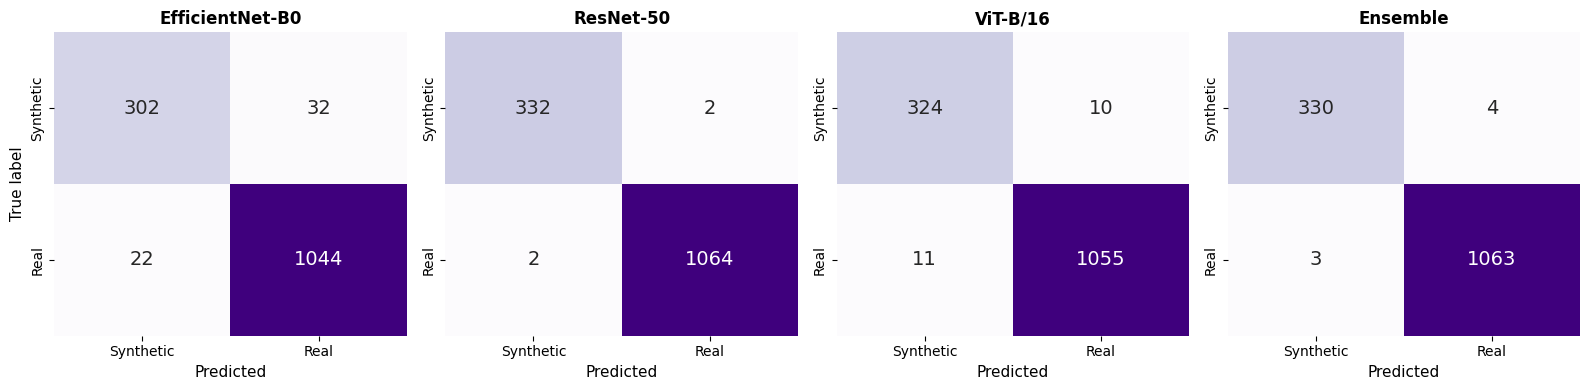

In [ ]:
# Confusion matrices — по одній на кожну модель
n_models = len(all_metrics)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

class_names = ['Synthetic', 'Real']
for i, (ax, (name, m)) in enumerate(zip(axes, all_metrics.items())):
    cm = np.array(m['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                annot_kws={'size': 14})
    ax.set_title(name, fontsize=12, fontweight='bold')
    if i == 0:
        ax.set_ylabel('True label', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
cm_path = OUTPUT_DIR / 'confusion_matrices.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
print(f"✓ Збережено {cm_path}")
plt.show()


✓ Збережено /content/roc_curves.png


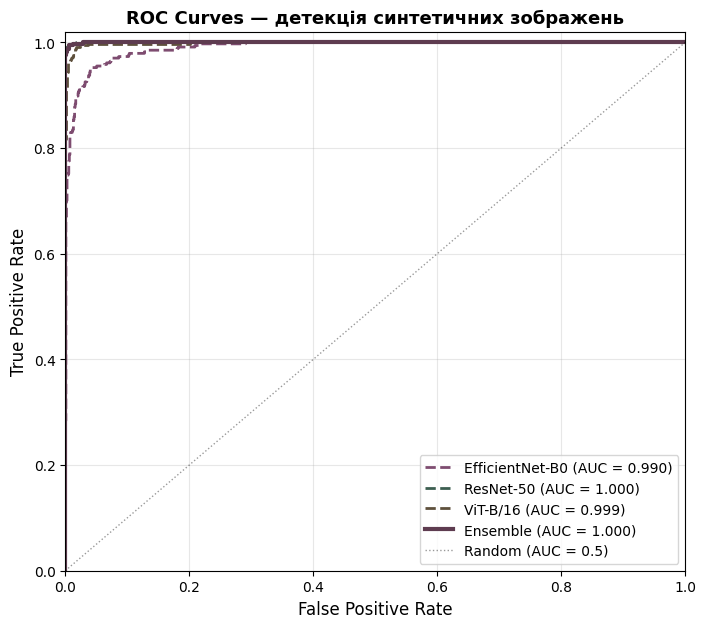

In [ ]:
# ROC curves
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

y_true_synth = (test_labels == CLASS_SYNTHETIC).astype(int)
colors = {'EfficientNet-B0': '#7e4c70', 'ResNet-50': '#3c5e50',
          'ViT-B/16': '#5e503c', 'Ensemble': '#5e3c50'}
styles = {'EfficientNet-B0': '--', 'ResNet-50': '--', 'ViT-B/16': '--', 'Ensemble': '-'}

for name, probs_real in predictions.items():
    probs_synth = 1 - probs_real
    fpr, tpr, _ = roc_curve(y_true_synth, probs_synth)
    roc_auc = auc(fpr, tpr)
    lw = 3 if name == 'Ensemble' else 2
    ax.plot(fpr, tpr, color=colors.get(name, '#888'),
            linestyle=styles.get(name, '-'), lw=lw,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.4, label='Random (AUC = 0.5)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — детекція синтетичних зображень', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

roc_path = OUTPUT_DIR / 'roc_curves.png'
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
print(f"✓ Збережено {roc_path}")
plt.show()


✓ Збережено /content/training_curves.png


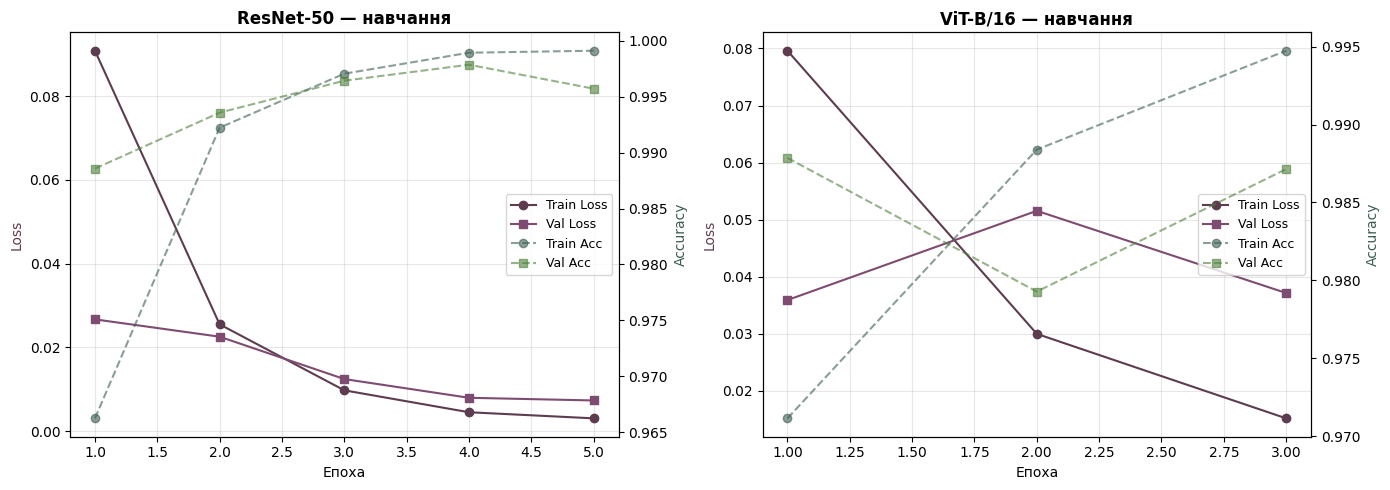

In [ ]:
# Криві навчання для ResNet-50 та ViT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, hist) in zip(axes, [('ResNet-50', history_r50), ('ViT-B/16', history_vit)]):
    epochs_range = list(range(1, len(hist['train_loss']) + 1))
    ax2 = ax.twinx()
    l1 = ax.plot(epochs_range, hist['train_loss'], 'o-', color='#5e3c50', label='Train Loss')
    l2 = ax.plot(epochs_range, hist['val_loss'], 's-', color='#7e4c70', label='Val Loss')
    l3 = ax2.plot(epochs_range, hist['train_acc'], 'o--', color='#3c5e50', label='Train Acc', alpha=0.6)
    l4 = ax2.plot(epochs_range, hist['val_acc'], 's--', color='#50803c', label='Val Acc', alpha=0.6)

    ax.set_xlabel('Епоха')
    ax.set_ylabel('Loss', color='#5e3c50')
    ax2.set_ylabel('Accuracy', color='#3c5e50')
    ax.set_title(f'{name} — навчання', fontweight='bold')
    ax.grid(alpha=0.3)

    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]
    ax.legend(lines, labels, loc='center right', fontsize=9)

plt.tight_layout()
curves_path = OUTPUT_DIR / 'training_curves.png'
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
print(f"✓ Збережено {curves_path}")
plt.show()


In [ ]:
# Збереження фінальних метрик
metrics_path = OUTPUT_DIR / 'metrics_ensemble.json'
output = {
    'dataset': 'Parveshiiii/AI-vs-Real',
    'test_size': int(len(test_labels)),
    'class_mapping': {'0': 'synthetic', '1': 'real'},
    'hyperparameters': {
        'image_size': IMAGE_SIZE,
        'batch_size_cnn': BATCH_SIZE_CNN,
        'batch_size_vit': BATCH_SIZE_VIT,
        'epochs': EPOCHS,
        'lr_start_cnn': LR_START_CNN,
        'lr_start_vit': LR_START_VIT,
        'lr_end': LR_END,
        'weight_decay': WEIGHT_DECAY,
        'optimizer': 'AdamW',
        'scheduler': 'CosineAnnealingLR',
    },
    'models': all_metrics,
}
with open(metrics_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f"✓ Метрики збережено: {metrics_path}")

# Підсумок для слайду
print("\n" + "=" * 75)
print("ФІНАЛЬНІ МЕТРИКИ ДЛЯ СЛАЙДУ 12 (ансамбль):")
print("=" * 75)
ens = all_metrics['Ensemble']
print(f"  Accuracy:  {ens['accuracy'] * 100:.1f}%")
print(f"  Precision: {ens['precision_synth'] * 100:.1f}%")
print(f"  Recall:    {ens['recall_synth'] * 100:.1f}%")
print(f"  F1-score:  {ens['f1_synth'] * 100:.1f}%")
print(f"  AUC-ROC:   {ens['auc_roc']:.3f}")

print("\n" + "=" * 75)
print("ФАЙЛИ ДЛЯ ЗАВАНТАЖЕННЯ:")
print("=" * 75)
for f in [r50_path, vit_path, metrics_path, cm_path, roc_path, curves_path]:
    if Path(f).exists():
        size_mb = Path(f).stat().st_size / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")


✓ Метрики збережено: /content/metrics_ensemble.json

ФІНАЛЬНІ МЕТРИКИ ДЛЯ СЛАЙДУ 12 (ансамбль):
  Accuracy:  99.5%
  Precision: 99.1%
  Recall:    98.8%
  F1-score:  99.0%
  AUC-ROC:   1.000

ФАЙЛИ ДЛЯ ЗАВАНТАЖЕННЯ:
  /content/resnet50_synthdetect.pth  (94.4 MB)
  /content/vit_b16_synthdetect.pth  (343.3 MB)
  /content/metrics_ensemble.json  (0.0 MB)
  /content/confusion_matrices.png  (0.0 MB)
  /content/roc_curves.png  (0.1 MB)
  /content/training_curves.png  (0.2 MB)
